# Climate Model Neural Network Prediction

<div>
<img src="https://raw.githubusercontent.com/illinois-mlp/MachineLearningForPhysics/main/img/Project_ClimateModels_splash.png" width=800></img>
</div>

## <span style="color:Orange">Background</span>

Climate change is one of the most important problems facing humanity in the years ahead, with numerous predicted regional or global changes such as:
- increases in sea level height [[1](https://doi.org/10.1029/2005GL024826)]
- increases in fire activity, fire risk, and burned area [[2](https://doi.org/10.1088/1748-9326/ab83a7), [3](https://doi.org/10.1029/2018GL080959), [4](https://doi.org/10.1073/pnas.1607171113)]
- likely increases in hurricane intensity [[5](https://www.climate.gov/news-features/understanding-climate/climate-change-probably-increasing-intensity-tropical-cyclones)]
- Changes in global atmospheric and oceanic circulation [[6](https://doi.org/10.1029/2024AV001297)]
  - potentially severe impacts, including a 10°C drop in surface temperature across Western Europe [[7](https://doi.org/10.1038/378165a0)], with large uncertainties [[8](https://doi.org/10.1038/s41561-025-01709-0)]

One of the most important tools used by climate scientists are computationally expensive numerical fluid dynamics simulations called General Circulation Models (GCMs). These models are used to predict and understand alternate historical, future or idealized climate scenarios (e.g. instantanously quadrupling $CO_2$ [[9](https://doi.org/10.1029/2012GL051607)], aquaplanet simulations [[10](https://doi.org/10.2151/jmsj1965.64.4_451)], large freshwater input from melting ice called 'hosing' experiments [[7](https://doi.org/10.1038/378165a0)], etc.). A partial list of widely used, community-endorsed climate model simulations is provided by the [Coupled Model Intercomparison Project (CMIP)](https://wcrp-cmip.org/cmip-phases/cmip7/). 

There are dozens of high-quality GCMs developed around the world. The four leading models in the United States are:

- the Geophysical Fluid Dynamics Laboratory (GFDL) model, operated by the National Oceanic and Atmospheric Administration (NOAA) in collaboration with Princeton University
- the NASA Goddard Institute for Space Studies (GISS) model, developed with Columbia University affiliations
- the Department of Energy’s Energy Exascale Earth System Model (E3SM)
- the Community Earth System Model (CESM) at the National Center for Atmospheric Research (NCAR)

All modeling centers develop unique models, with different physical representations of processes resulting in unique simulations spanning much of the uncertainty in the Earth System. In 2021 1/2 of the 2021 Nobel Prize in Physics was given to Syukuro Manabe and Klaus Hasselman, pioneers in global climate modeling', ["for the physical modelling of Earth’s climate, quantifying variability and reliably predicting global warming"](https://www.nobelprize.org/prizes/physics/2021/summary/). In 2026 the next phase of CMIP (CMIP7) will be out, resulting in all global modeling centers producing model simulations to the scientific community, with improvements and new experiments being ran.

## <span style="color:Orange">Overview</span>

This notebook will have three goals:
1. Learning to work with spatio-temporal climate model output
2. Working with (small) ensembles of climate models
3. Implementing a simple neural network to predict monthly surface temperature 

## <span style="color:Orange">Questions (Conceptual)</span>

### <span style="color:Green">Question 01</span>

What are some reasons different General Circulation Models (GCMs) produce different output?

### <span style="color:Green">Question 02</span>

Briefly explain what is meant by the resolution of a climate model.

### <span style="color:Green">Question 03</span>

What is the value of multiple models? Should efforts be focused on "one model to rule them all"? Explain the idea of model hierarchies and why they are useful [[11](https://doi.org/10.1029/2018RG000607)] 

## <span style="color:Orange">Data Sources</span>

We now will start to work with model output. Climate model output is extremely large, so it is common to subset by time, variable, or location. Additionally there is dozens of different models, different simulations for each model, and different versions of the same model due to improvements over time. Dealing with these 'super ensembles' is not feasable without working on [High Performance Computing (HPC) clusters](https://www.exascaleproject.org/research-project/e3sm-mmf/). Thankfully, the community realizes this and makes the simulation output relatively easy to access with limited resources via the [ESGF portal](https://metagrid.esgf-west.org/search).

### Downloading data

`wget` scripts are the preferred method for downloading and accessing climate model simulation output. Because of the nature of this project, we will not use `wget` scripts, nor the alternative data transfer tool known as globus. We will download two climate model output.

These two models are from CMIP3[12](https://wcrp-cmip.org/cmip-phases/cmip3/), an older climate model intercomparison project:

- GFDL_CM2.0, historical [[13](https://doi.org/10.1175/JCLI3629.1)]
- NCAR_CCSM3.0, historical [[14](https://doi.org/10.1175/JCLI3761.1)]

Historical simulations simulate the climate from 1850-2000. <br> We will first download data from GFDL_CM2.0

In [1]:
# imports 
import os
import urllib.request
import hashlib
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob as glob

/storage/work/cta5244/.conda/envs/phys450_env/lib/python3.10/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [4]:
# run this cell
url = "http://esgf-node.ornl.gov/thredds/fileServer/cmip3_data/data2/20c3m/atm/mo/tas/gfdl_cm2_0/run1/tas_A1.186101-200012.nc"
original_filename = "tas_A1.186101-200012.nc"
expected_hash = "f0a31b467db7449b8cb1172392d49153086749572a9547bef79a95bd3ce72724"

final_filename = "gfdl_cm2_1861_2000_historical_surfacetemperature.nc"

def verify_file(filepath, expected_hash):
    if not os.path.exists(filepath):
        return False
    sha256 = hashlib.sha256()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            sha256.update(chunk)
    return sha256.hexdigest() == expected_hash

if verify_file(final_filename, expected_hash) or verify_file(original_filename, expected_hash):
    print(f"File is already downloaded and verified.")
else:
    print(f"Downloading GFDL dataset...")
    urllib.request.urlretrieve(url, original_filename)
    
    # Verify the fresh download
    if verify_file(original_filename, expected_hash):
        print("Download complete and SHA256 verified!")
    else:
        print("Warning: File downloaded, but checksum failed.")

if os.path.exists(original_filename) and not os.path.exists(final_filename):
    os.rename(original_filename, final_filename)
    print(f"Renamed to: {final_filename}")

print("\nDone! Ready for analysis.")

Download complete and SHA256 verified!
Renamed to: gfdl_cm2_1861_2000_historical_surfacetemperature.nc

Done! Ready for analysis.


## Analyzing Climate Model Simulation (GFDL_CM2.0)

After downloading the data we can subset and use some python libraries to help with the plotting.

In [5]:
# Here we open_dataset using xarray, then take the time mean
gfdl_hist = xr.open_dataset('gfdl_cm2_1816_2000_historical_surfacetemperature.nc')
# we can also subtract out 273.15 to make the Kelvin to Celcius conversion
gfdl_hist['tas'] = gfdl_hist['tas'] - 273.15
time_mean_gfdl_hist = gfdl_hist.mean("time")

In [6]:
time_mean_gfdl_hist.head()

<xarray.Dataset> Size: 348B
Dimensions:   (lon: 5, bnds: 2, lat: 5)
Coordinates:
  * lon       (lon) float64 40B 1.25 3.75 6.25 8.75 11.25
  * lat       (lat) float64 40B -89.0 -87.0 -85.0 -83.0 -81.0
    height    float64 8B ...
Dimensions without coordinates: bnds
Data variables:
    lon_bnds  (lon, bnds) float64 80B 0.0 2.5 2.5 5.0 5.0 7.5 7.5 10.0 10.0 12.5
    lat_bnds  (lat, bnds) float64 80B -90.0 -88.0 -88.0 ... -82.0 -82.0 -80.0
    tas       (lat, lon) float32 100B -46.75 -46.95 -47.19 ... -45.77 -46.87

`time_mean_gfdl_hist` is now a multidimensional [xarray dataset](https://docs.xarray.dev/en/stable/generated/xarray.Dataset.html), with `lon` and `lat` defining the spatial dimensions and `tas` giving the mean surface temperature values over the entire time domain. [Xarray](https://docs.xarray.dev/en/stable/) is a standard tool for working with climate data because it provides convenient built-in functionality for labeled multidimensional arrays. It draws on functionality from [pandas](https://pandas.pydata.org/) and [NumPy](https://numpy.org/), and also supports more advanced workflows such as [chunking and distributed computing](https://docs.xarray.dev/en/stable/user-guide/dask.html). <br>
Now we can plot the time mean over space with the below code:

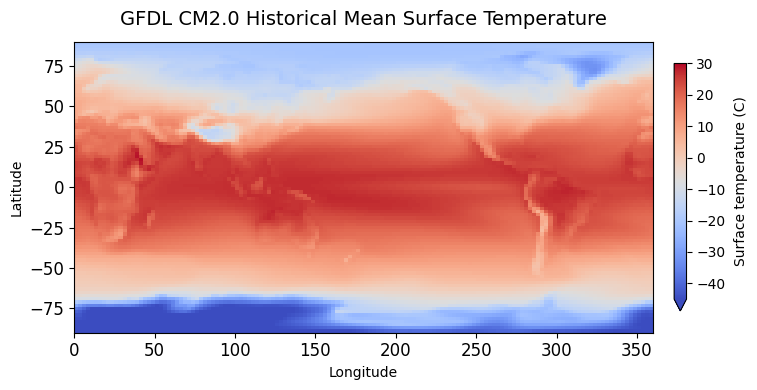

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
im = time_mean_gfdl_hist.tas.plot(
    ax=ax,
    cmap="coolwarm",
    robust=True,
    vmin = -45,
    vmax= 30,
    cbar_kwargs={
        "label": "Surface temperature (C)",
        "shrink": 0.85,
        "pad": 0.03
    }
)
im.colorbar.set_label("Surface temperature (C)", labelpad=6)
ax.set_title("GFDL CM2.0 Historical Mean Surface Temperature", fontsize=14, pad=12)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.tick_params(labelsize=12)
plt.tight_layout()

We can also subset the dataset by time:

In [8]:
# isel is an index selection where 0 is the first index, up to index 3
multiple_times_select_by_time_gfdl = gfdl_hist.isel(time=[0,3])
# or for a single time
single_times_select_by_time_gfdl = gfdl_hist.isel(time=0)

Or we can group by year and look at a single year:

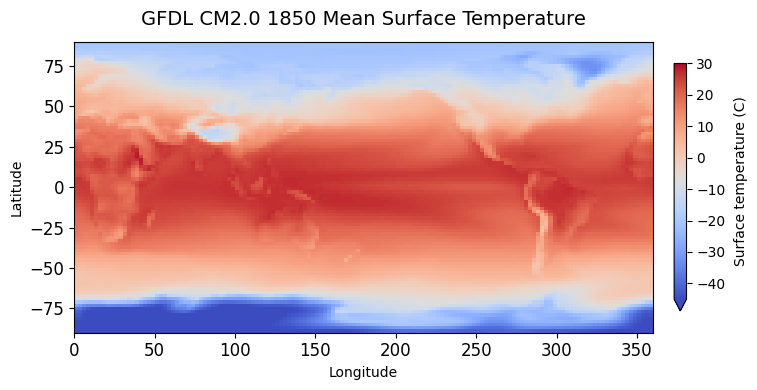

In [9]:
yearly_mean_gfdl_hist = gfdl_hist.groupby('time.year').mean()
single_year_gfdl_hist = yearly_mean_gfdl_hist.isel(year=0)
fig, ax = plt.subplots(figsize=(8, 4))
im = single_year_gfdl_hist.tas.plot(
    ax=ax,
    cmap="coolwarm",
    robust=True,
    vmin = -45,
    vmax= 30,
    cbar_kwargs={
        "label": "Surface temperature (K)",
        "shrink": 0.85,
        "pad": 0.03
    }
)
im.colorbar.set_label("Surface temperature (C)", labelpad=6)
ax.set_title("GFDL CM2.0 1850 Mean Surface Temperature", fontsize=14, pad=12)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.tick_params(labelsize=12)
plt.tight_layout()

## <span style="color:Orange">Questions (Computational Pt 1.)</span>

### <span style="color:Green">Question 05</span>

Oftentimes its more valuable to look at temperature anomalies, i.e. by taking a mean from the first N years of data, then removing that mean from each location over the time domain of interest. In the cell below please take a mean for the first ~50 years of the simulation at each grid cell, then remove that mean from the entire simulation and plot the year 2000. 

### <span style="color:Green">Question 06</span>

Another common way to analyze spatio-temporal data is to plot the regression slope of the yearly values. By fitting a linear trend to the field of interest, temperature in this case, we can quantify the rate at which temperature changes over time. First, group the data by year and compute the annual mean. Then fit a regression at each location and plot the resulting slope field. [Np.polyfit](https://numpy.org/doc/stable/reference/generated/numpy.polyfit.html) may be useful for this task. It is also bad practice to loop over every longitude-latitude combination when the operation can be vectorized.

## Neural Network for yearly predictions

We are in the middle of a wave of exciting new research applying machine learning to problems in Earth, atmospheric, and climate science.

A few especially notable recent projects and advances include:
 - AI-based climate and weather models
   - SamudrACE [[15](https://doi.org/10.48550/arXiv.2509.12490)]
   - NeuralGCM (Google) [[16](https://doi.org/10.1038/s41586-024-07744-y)]
     - (first author did his PhD in physics at UIUC with Bryan Clark!)
   - GraphCast (Google) [[17](https://doi.org/10.48550/arXiv.2212.12794)]
   - Prithvi WxC (IBM, NASA) [[18](https://doi.org/10.48550/arXiv.2409.13598)]
 - ML for climate model parameterizations
   - [M²LInES (NYU, Schmidt Sciences)](https://m2lines.github.io/about/)
   - [Climate Modeling Alliance (MIT, Caltech, Schmidt Sciences)](https://clima.caltech.edu/)


We will focus on a simple implementation of neural network to predict temperature. It will be helpful to learn to subset by location. The below code slices lon / lat to make a box over North America and demonstrates seasonality in the gfdl climate model.

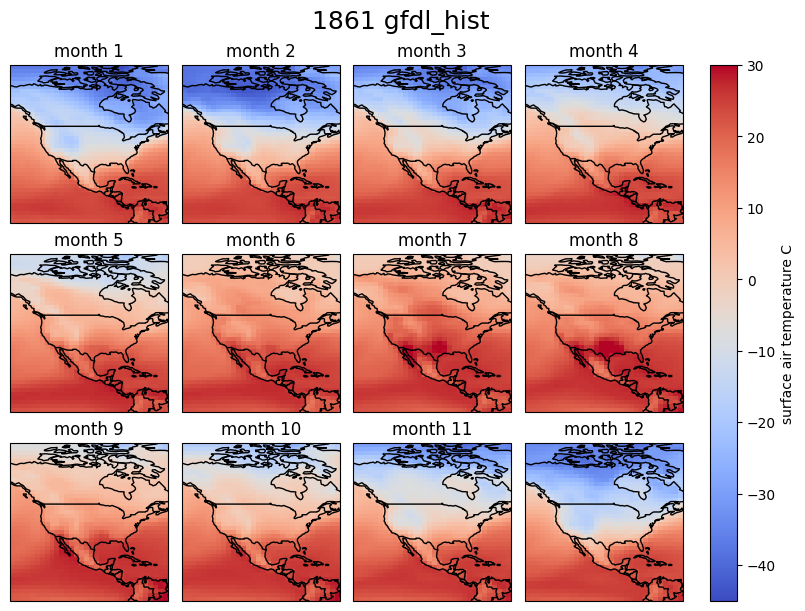

In [99]:
tas_sub = gfdl_hist.sel(lat=slice(0, 80), lon=slice(220, 300))

fig, axes = plt.subplots(
    3, 4,
    figsize=(8, 6),
    subplot_kw={"projection": ccrs.PlateCarree()}, layout="constrained"
)
plt.suptitle(f'{tas_sub.isel(time=0).time.item().year} gfdl_hist', fontsize=18)
axes = axes.ravel()

for i in range(12):
    ax = axes[i]

    im = tas_sub.isel(time=i).tas.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        vmin=-45,
        vmax=30,
        cmap="coolwarm",
        add_colorbar=False
    )

    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linewidth=1)
    ax.set_extent([220, 300, 0, 80], crs=ccrs.PlateCarree())

    t = tas_sub.isel(time=i).time.item()
    ax.set_title(f"month {t.month}")

cbar = fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.04, pad=0.04)
cbar.set_label("surface air temperature C")

## <span style="color:Orange">Questions (NN prediction)</span>

### <span style="color:Green">Question 07</span>

Given all of the above code implement a convolutional neural network to predict monthly temperature anomalies, focusing on North America. Use an 80/20 split for training, based on time. Please plot the time series for surface temperature for the closest gridpoint to Champaign IL using `dataset.sel(lon=target_lon, method="nearest")`, both for the training, NN predicted and climate model predicted. Plot RMSE spatially.

## <span style="color:Orange">Questions (NN prediction (2 members))</span>

Run the next cell to download one other climate model output.

In [3]:
# saves as one file, only run cell once
datasets = [
    ("tas_A1.20C3M_1.CCSM.atmm.1980-01_cat_1989-12.nc", "http://esgf-node.ornl.gov/thredds/fileServer/cmip3_data/data2/20c3m/atm/mo/tas/ncar_ccsm3_0/run1/tas_A1.20C3M_1.CCSM.atmm.1980-01_cat_1989-12.nc", "8d0822cdf36f97928bc199c1ffcce0f70f5f61befb4aa3a223883feba2120af3"),
    ("tas_A1.20C3M_1.CCSM.atmm.1910-01_cat_1919-12.nc", "http://esgf-node.ornl.gov/thredds/fileServer/cmip3_data/data2/20c3m/atm/mo/tas/ncar_ccsm3_0/run1/tas_A1.20C3M_1.CCSM.atmm.1910-01_cat_1919-12.nc", "ae8c49cd4c9bb930744babea7f399fc49a56d9b195d3c4815ecb60ccdb234088"),
    ("tas_A1.20C3M_1.CCSM.atmm.1940-01_cat_1949-12.nc", "http://esgf-node.ornl.gov/thredds/fileServer/cmip3_data/data2/20c3m/atm/mo/tas/ncar_ccsm3_0/run1/tas_A1.20C3M_1.CCSM.atmm.1940-01_cat_1949-12.nc", "54f68a930e89849570ec6749985f0ded1f385c1d8199b869e49f646730de821d"),
    ("tas_A1.20C3M_1.CCSM.atmm.1950-01_cat_1959-12.nc", "http://esgf-node.ornl.gov/thredds/fileServer/cmip3_data/data2/20c3m/atm/mo/tas/ncar_ccsm3_0/run1/tas_A1.20C3M_1.CCSM.atmm.1950-01_cat_1959-12.nc", "204f3cbb05ae1add8e85ee5b4cd0406847ceb59ea480db892ec80e5dcce9de65"),
    ("tas_A1.20C3M_1.CCSM.atmm.1900-01_cat_1909-12.nc", "http://esgf-node.ornl.gov/thredds/fileServer/cmip3_data/data2/20c3m/atm/mo/tas/ncar_ccsm3_0/run1/tas_A1.20C3M_1.CCSM.atmm.1900-01_cat_1909-12.nc", "3b00c20efae648251a5fdefdabbfa80526b1280efa3e3566ecf6ec41dcde4b57"),
    ("tas_A1.20C3M_1.CCSM.atmm.1930-01_cat_1939-12.nc", "http://esgf-node.ornl.gov/thredds/fileServer/cmip3_data/data2/20c3m/atm/mo/tas/ncar_ccsm3_0/run1/tas_A1.20C3M_1.CCSM.atmm.1930-01_cat_1939-12.nc", "ec2b145490f3c7e920525d0934107a80a4a7552794c872cc74f9447f8dd8dc36"),
    ("tas_A1.20C3M_1.CCSM.atmm.1970-01_cat_1979-12.nc", "http://esgf-node.ornl.gov/thredds/fileServer/cmip3_data/data2/20c3m/atm/mo/tas/ncar_ccsm3_0/run1/tas_A1.20C3M_1.CCSM.atmm.1970-01_cat_1979-12.nc", "8f26731776d2fac6d54515cca8aa72ad847d9d33cfd91f6ebc27c63b17124189"),
    ("tas_A1.20C3M_1.CCSM.atmm.1870-01_cat_1879-12.nc", "http://esgf-node.ornl.gov/thredds/fileServer/cmip3_data/data2/20c3m/atm/mo/tas/ncar_ccsm3_0/run1/tas_A1.20C3M_1.CCSM.atmm.1870-01_cat_1879-12.nc", "23b9f725d311a955454fa86f98a5c8743fd5e27bb12d1b402ac68d3f67e1e26d"),
    ("tas_A1.20C3M_1.CCSM.atmm.1890-01_cat_1899-12.nc", "http://esgf-node.ornl.gov/thredds/fileServer/cmip3_data/data2/20c3m/atm/mo/tas/ncar_ccsm3_0/run1/tas_A1.20C3M_1.CCSM.atmm.1890-01_cat_1899-12.nc", "32b8ac00c83204c203452e05dbedb0132bda81c623f2a0a521c851e48ae82068"),
    ("tas_A1.20C3M_1.CCSM.atmm.1920-01_cat_1929-12.nc", "http://esgf-node.ornl.gov/thredds/fileServer/cmip3_data/data2/20c3m/atm/mo/tas/ncar_ccsm3_0/run1/tas_A1.20C3M_1.CCSM.atmm.1920-01_cat_1929-12.nc", "9c3d344ff505d7702fb68f2cdc52972a97a3c3b15c4fefafac968135d6713b34"),
    ("tas_A1.20C3M_1.CCSM.atmm.1960-01_cat_1969-12.nc", "http://esgf-node.ornl.gov/thredds/fileServer/cmip3_data/data2/20c3m/atm/mo/tas/ncar_ccsm3_0/run1/tas_A1.20C3M_1.CCSM.atmm.1960-01_cat_1969-12.nc", "0e21367263d1016d15d225ca01747143f67dcbe9be9af2f1b112e193c9bcd297"),
    ("tas_A1.20C3M_1.CCSM.atmm.1990-01_cat_1999-12.nc", "http://esgf-node.ornl.gov/thredds/fileServer/cmip3_data/data2/20c3m/atm/mo/tas/ncar_ccsm3_0/run1/tas_A1.20C3M_1.CCSM.atmm.1990-01_cat_1999-12.nc", "ab5a096e51ed997cfd1b05a0f95ddbc566bdf22aa4f6c60e6c504118887141e1"),
    ("tas_A1.20C3M_1.CCSM.atmm.1880-01_cat_1889-12.nc", "http://esgf-node.ornl.gov/thredds/fileServer/cmip3_data/data2/20c3m/atm/mo/tas/ncar_ccsm3_0/run1/tas_A1.20C3M_1.CCSM.atmm.1880-01_cat_1889-12.nc", "b77578c2b170c05609fc8f76c49ca2698bdce030572136e72774d080a0732b88")
]

def verify_file(filepath, expected_hash):
    if not os.path.exists(filepath):
        return False
    sha256 = hashlib.sha256()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            sha256.update(chunk)
    return sha256.hexdigest() == expected_hash

file_list = []
print("--- Starting Downloads ---")
for filename, url, expected_hash in datasets:
    file_list.append(filename)
    
    if verify_file(filename, expected_hash):
        print(f"[{filename}] Verified. Skipping download.")
    else:
        print(f"[{filename}] Downloading...")
        urllib.request.urlretrieve(url, filename)

print("\n--- Combining Data with xarray ---")
final_filename = 'ncar_ccsm30_1870_2000_historical_surfacetemperature.nc'

try:
    ccsm = xr.open_mfdataset(sorted(file_list))
    ccsm.to_netcdf(final_filename)
    ccsm.close() 
    print(f"Successfully saved combined dataset to: {final_filename}")
    print("\n--- Cleaning Up ---")
    for f in file_list:
        if os.path.exists(f):
            os.remove(f)
            print(f"Deleted chunk: {f}")
            
    print("\nAll done!")

except Exception as e:
    print(f"\nAn error occurred during xarray processing: {e}")
    print("Skipping cleanup so you can inspect the chunk files.")

--- Starting Downloads ---
[tas_A1.20C3M_1.CCSM.atmm.1980-01_cat_1989-12.nc] Verified. Skipping download.
[tas_A1.20C3M_1.CCSM.atmm.1910-01_cat_1919-12.nc] Verified. Skipping download.
[tas_A1.20C3M_1.CCSM.atmm.1940-01_cat_1949-12.nc] Verified. Skipping download.
[tas_A1.20C3M_1.CCSM.atmm.1950-01_cat_1959-12.nc] Verified. Skipping download.
[tas_A1.20C3M_1.CCSM.atmm.1900-01_cat_1909-12.nc] Verified. Skipping download.
[tas_A1.20C3M_1.CCSM.atmm.1930-01_cat_1939-12.nc] Verified. Skipping download.
[tas_A1.20C3M_1.CCSM.atmm.1970-01_cat_1979-12.nc] Verified. Skipping download.
[tas_A1.20C3M_1.CCSM.atmm.1870-01_cat_1879-12.nc] Verified. Skipping download.
[tas_A1.20C3M_1.CCSM.atmm.1890-01_cat_1899-12.nc] Verified. Skipping download.
[tas_A1.20C3M_1.CCSM.atmm.1920-01_cat_1929-12.nc] Verified. Skipping download.
[tas_A1.20C3M_1.CCSM.atmm.1960-01_cat_1969-12.nc] Verified. Skipping download.
[tas_A1.20C3M_1.CCSM.atmm.1990-01_cat_1999-12.nc] Verified. Skipping download.
[tas_A1.20C3M_1.CCSM.atmm

### <span style="color:Green">Question 08</span>

You will notice that climate models from different modeling centers provide output differently. This can be cumbersome dealing with, especially with different resolutions, grids, or conventions. Please make the NCAR CSSM output in the same format as the gfdl output, regridding to the same resolution. **Create one xarray dataset where the variables are gfdl_tas, and cssm_tas**. Regrid using xarray or xesmf regridding.

### <span style="color:Green">Question 09</span>

Implement another convolutional neural network, but using two climate models as input. Use same instructions as above, but compare against both climate models for predictions.

## <span style="color:Orange">Questions (Overview / Summary)</span>

### <span style="color:Green">Question 10</span>

Write a short paragraph on one of the projects / advances from above. Talk about the relative importance, the training, and the architecture. What are some of the main benefits of ML methods in earth sciences?  

## <span style="color:Orange">References</span>

__[<span style="color:Blue">1</span>]__ Church, J. A., & White, N. J. (2006). A 20th century acceleration in global sea-level rise. Geophysical Research Letters, 33(1). https://doi.org/10.1029/2005GL024826 <br>

__[<span style="color:Blue">2</span>]__ Goss, M., Swain, D. L., Abatzoglou, J. T., Sarhadi, A., Kolden, C. A., Williams, A. P., & Diffenbaugh, N. S. (2020). Climate change is increasing the likelihood of extreme autumn wildfire conditions across California. Environmental Research Letters, 15(9), 094016. https://doi.org/10.1088/1748-9326/ab83a7 <br>

__[<span style="color:Blue">3</span>]__ Abatzoglou, J. T., Williams, A. P., & Barbero, R. (2019). Global Emergence of Anthropogenic Climate Change in Fire Weather Indices. Geophysical Research Letters, 46(1), 326–336. https://doi.org/10.1029/2018GL080959 <br>

__[<span style="color:Blue">4</span>]__ Abatzoglou, J. T., & Williams, A. P. (2016). Impact of anthropogenic climate change on wildfire across western US forests. Proceedings of the National Academy of Sciences, 113(42), 11770–11775. https://doi.org/10.1073/pnas.1607171113

__[<span style="color:Blue">5</span>]__ Knutson, T. R., Chung, M. V., Vecchi, G., Sun, J., Hsieh, T.-L., & Smith, A. J. P. (2021). Climate change is probably increasing the intensity of tropical cyclones. NOAA Climate.gov. https://www.climate.gov/news-features/understanding-climate/climate-change-probably-increasing-intensity-tropical-cyclones

__[<span style="color:Blue">6</span>]__ Shaw, T. A., Arblaster, J. M., Birner, T., Butler, A. H., Domeisen, D. I. V., Garfinkel, C. I., Garny, H., Grise, K. M., & Karpechko, A. Yu. (2024). Emerging Climate Change Signals in Atmospheric Circulation. AGU Advances, 5(6), e2024AV001297. https://doi.org/10.1029/2024AV001297

__[<span style="color:Blue">7</span>]__ Manabe, S., & Stouffer, R. J. (1995). Simulation of abrupt climate change induced by freshwater input to the North Atlantic Ocean. Nature, 378(6553), 165–167. https://doi.org/10.1038/378165a0

__[<span style="color:Blue">8</span>]__ Bonan, D. B., Thompson, A. F., Schneider, T., Zanna, L., Armour, K. C., & Sun, S. (2025). Observational constraints imply limited future Atlantic meridional overturning circulation weakening. Nature Geoscience, 18(6), 479–487. https://doi.org/10.1038/s41561-025-01709-0

__[<span style="color:Blue">9</span>]__ Andrews, T., Gregory, J. M., Webb, M. J., & Taylor, K. E. (2012). Forcing, feedbacks and climate sensitivity in CMIP5 coupled atmosphere‐ocean climate models. Geophysical Research Letters, 39(9), 2012GL051607. https://doi.org/10.1029/2012GL051607

__[<span style="color:Blue">10</span>]__ Hayashi, Y.-Y., & Sumi, A. (1986). The 30-40 Day Oscillations Simulated in an “Aqua Planet” Model. Journal of the Meteorological Society of Japan. Ser. II, 64(4), 451–467. https://doi.org/10.2151/jmsj1965.64.4_451

__[<span style="color:Blue">11</span>]__ Maher, P., Gerber, E. P., Medeiros, B., Merlis, T. M., Sherwood, S., Sheshadri, A., Sobel, A. H., Vallis, G. K., Voigt, A., & Zurita-Gotor, P. (2019). Model Hierarchies for Understanding Atmospheric Circulation. Reviews of Geophysics, 57(2), 250–280. https://doi.org/10.1029/2018RG000607

__[<span style="color:Blue">12</span>]__ Meehl, G. A., Covey, C., Delworth, T., Latif, M., McAvaney, B., Mitchell, J. F. B., Stouffer, R. J., & Taylor, K. E. (2007). THE WCRP CMIP3 Multimodel Dataset: A New Era in Climate Change Research. Bulletin of the American Meteorological Society, 88(9), 1383–1394. https://doi.org/10.1175/BAMS-88-9-1383

__[<span style="color:Blue">13</span>]__ Delworth, T. L., Broccoli, A. J., Rosati, A., Stouffer, R. J., Balaji, V., Beesley, J. A., Cooke, W. F., Dixon, K. W., Dunne, J., Dunne, K. A., Durachta, J. W., Findell, K. L., Ginoux, P., Gnanadesikan, A., Gordon, C. T., Griffies, S. M., Gudgel, R., Harrison, M. J., Held, I. M., … Zhang, R. (2006). GFDL’s CM2 Global Coupled Climate Models. Part I: Formulation and Simulation Characteristics. Journal of Climate, 19(5), 643–674. https://doi.org/10.1175/JCLI3629.1

__[<span style="color:Blue">14</span>]__ Collins, W. D., Bitz, C. M., Blackmon, M. L., Bonan, G. B., Bretherton, C. S., Carton, J. A., Chang, P., Doney, S. C., Hack, J. J., Henderson, T. B., Kiehl, J. T., Large, W. G., McKenna, D. S., Santer, B. D., & Smith, R. D. (2006). The Community Climate System Model Version 3 (CCSM3). Journal of Climate, 19(11), 2122–2143. https://doi.org/10.1175/JCLI3761.1

__[<span style="color:Blue">15</span>]__ Duncan, J. P. C., Wu, E., Dheeshjith, S., Subel, A., Arcomano, T., Clark, S. K., Henn, B., Kwa, A., McGibbon, J., Perkins, W. A., Gregory, W., Fernandez-Granda, C., Busecke, J., Watt-Meyer, O., Hurlin, W. J., Adcroft, A., Zanna, L., & Bretherton, C. (2026). SamudrACE: Fast and Accurate Coupled Climate Modeling with 3D Ocean and Atmosphere Emulators (arXiv:2509.12490; Version 2). arXiv. https://doi.org/10.48550/arXiv.2509.12490

__[<span style="color:Blue">16</span>]__ Kochkov, D., Yuval, J., Langmore, I., Norgaard, P., Smith, J., Mooers, G., Klöwer, M., Lottes, J., Rasp, S., Düben, P., Hatfield, S., Battaglia, P., Sanchez-Gonzalez, A., Willson, M., Brenner, M. P., & Hoyer, S. (2024). Neural general circulation models for weather and climate. Nature, 632(8027), 1060–1066. https://doi.org/10.1038/s41586-024-07744-y

__[<span style="color:Blue">17</span>]__ Lam, R., Sanchez-Gonzalez, A., Willson, M., Wirnsberger, P., Fortunato, M., Alet, F., Ravuri, S., Ewalds, T., Eaton-Rosen, Z., Hu, W., Merose, A., Hoyer, S., Holland, G., Vinyals, O., Stott, J., Pritzel, A., Mohamed, S., & Battaglia, P. (2023). GraphCast: Learning skillful medium-range global weather forecasting (arXiv:2212.12794). arXiv. https://doi.org/10.48550/arXiv.2212.12794

__[<span style="color:Blue">18</span>]__ Schmude, J., Roy, S., Trojak, W., Jakubik, J., Civitarese, D. S., Singh, S., Kuehnert, J., Ankur, K., Gupta, A., Phillips, C. E., Kienzler, R., Szwarcman, D., Gaur, V., Shinde, R., Lal, R., Silva, A. D., Diaz, J. L. G., Jones, A., Pfreundschuh, S., … Ramachandran, R. (2024). Prithvi WxC: Foundation Model for Weather and Climate (arXiv:2409.13598). arXiv. https://doi.org/10.48550/arXiv.2409.13598


## <span style="color:Orange">Acknowledgements</span>

* Initial version: [Theo Avila](https://www.linkedin.com/in/theo-avila/) with some guidence from Mark Neubauer

© Copyright 2026